## Section 08
### Filtering DataFrames

* 61: Filtering DataFrames With a Boolean Series
* 62: Filtering with Comparison Operators
* 63: The Between Method
* 64: The isin() Method
* 65: Combining Conditions using AND
* 66: Combining Conditions using OR
* 67: Bitwise Negation
* 68: isna() and notna() Methods
* 69: Filtering + Plotting Examples

In [1]:
import pandas as pd

In [2]:
houses = pd.read_csv('../datasets/data/kc_house_data.csv')
titanic = pd.read_csv('../datasets/data/titanic.csv')
netflix = pd.read_csv('../datasets/data/netflix_titles.csv', sep='|', index_col=0)

In [3]:
df = titanic.head()
df.sex == 'female'

0     True
1    False
2     True
3    False
4     True
Name: sex, dtype: bool

In [4]:
df[df.sex == 'female']

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [5]:
df[df.survived == 1]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"


In [6]:
titanic[titanic.survived == 1]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48,0,0,19952,26.55,E12,S,3,?,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63,1,0,13502,77.9583,D7,S,10,?,"Hudson, NY"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53,2,0,11769,51.4792,C101,S,D,?,"Bayside, Queens, NY"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261,3,1,"Turkula, Mrs. (Hedwig)",female,63,0,0,4134,9.5875,?,S,15,?,?
1277,3,1,"Vartanian, Mr. David",male,22,0,0,2658,7.225,?,C,13 15,?,?
1286,3,1,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38,0,0,2688,7.2292,?,C,C,?,?
1290,3,1,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,363272,7,?,S,?,?,?


In [7]:
titanic[titanic.age == '18'].head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
11,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18,1,0,PC 17757,227.525,C62 C64,C,4,?,"New York, NY"
198,1,1,"Marvin, Mrs. Daniel Warner (Mary Graham Carmic...",female,18,1,0,113773,53.1,D30,S,10,?,"New York, NY"
228,1,0,"Penasco y Castellana, Mr. Victor de Satode",male,18,1,0,PC 17758,108.9,C65,C,?,?,"Madrid, Spain"
250,1,1,"Ryerson, Miss. Emily Borie",female,18,2,2,PC 17608,262.375,B57 B59 B63 B66,C,4,?,"Haverford, PA / Cooperstown, NY"
270,1,1,"Smith, Mrs. Lucien Philip (Mary Eloise Hughes)",female,18,1,0,13695,60,C31,S,6,?,"Huntington, WV"


<Axes: >

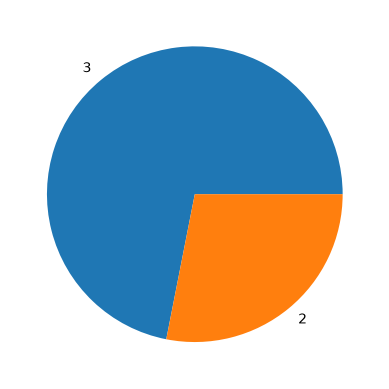

In [8]:
titanic[titanic.pclass != 1].pclass.value_counts().plot(kind='pie')

In [12]:
houses[houses.price >= 5000000] 

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1164,1247600105,20141020T000000,5110800.0,5,5.25,8010,45517,2.0,1,4,...,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
1315,7558700030,20150413T000000,5300000.0,6,6.00,7390,24829,2.0,1,4,...,12,5000,2390,1991,0,98040,47.5631,-122.210,4320,24619
1448,8907500070,20150413T000000,5350000.0,5,5.00,8000,23985,2.0,0,4,...,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
3914,9808700762,20140611T000000,7062500.0,5,4.50,10040,37325,2.0,1,2,...,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
4411,2470100110,20140804T000000,5570000.0,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
7252,6762700020,20141013T000000,7700000.0,6,8.00,12050,27600,2.5,0,3,...,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
9254,9208900037,20140919T000000,6885000.0,6,7.75,9890,31374,2.0,0,4,...,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730


In [17]:
houses[houses.bedrooms.between(5, 7)].bedrooms.value_counts()

bedrooms
5    1601
6     272
7      38
Name: count, dtype: int64

In [25]:
countries = ['India', 'Japan', 'South Korea']
netflix[netflix['country'].isin(countries)].country.value_counts()

country
India          972
Japan          245
South Korea    199
Name: count, dtype: int64

In [28]:
women = titanic.sex == 'female'
died = titanic.survived == 0

titanic[women & died]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
105,1,0,"Evans, Miss. Edith Corse",female,36,0,0,PC 17531,31.6792,A29,C,?,?,"New York, NY"
169,1,0,"Isham, Miss. Ann Elizabeth",female,50,0,0,PC 17595,28.7125,C49,C,?,?,"Paris, France New York, NY"
286,1,0,"Straus, Mrs. Isidor (Rosalie Ida Blun)",female,63,1,0,PC 17483,221.7792,C55 C57,S,?,?,"New York, NY"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1273,3,0,"Vander Planke, Miss. Augusta Maria",female,18,2,0,345764,18,?,S,?,?,?
1276,3,0,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31,1,0,345763,18,?,S,?,?,?
1279,3,0,"Vestrom, Miss. Hulda Amanda Adolfina",female,14,0,0,350406,7.8542,?,S,?,?,?
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,?,C,?,328,?


In [31]:
houses[(houses['waterfront'] == 1) & (houses['price'] < 500000)]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
264,2123039032,20141027T000000,369900.0,1,0.75,760,10079,1.0,1,4,...,5,760,0,1936,0,98070,47.4683,-122.438,1230,14267
1168,3523029041,20141009T000000,290000.0,2,0.75,440,8313,1.0,1,3,...,5,440,0,1943,0,98070,47.4339,-122.512,880,26289
1949,1922039062,20150420T000000,480000.0,2,1.50,1008,26487,1.0,1,4,...,6,1008,0,1943,2002,98070,47.3853,-122.479,1132,24079
3829,8550001515,20141001T000000,429592.0,2,2.75,1992,10946,1.5,1,4,...,6,1288,704,1903,0,98070,47.3551,-122.475,1110,8328
6102,222029026,20140917T000000,340000.0,2,0.75,1060,48292,1.0,1,2,...,6,560,500,1947,0,98070,47.4285,-122.511,750,80201
8277,221029019,20150428T000000,400000.0,3,2.50,2090,32718,2.0,1,4,...,7,1550,540,1919,1983,98070,47.3338,-122.511,1200,192268
8450,121039042,20150313T000000,425000.0,3,2.75,3610,107386,1.5,1,3,...,8,3130,480,1918,1962,98023,47.3351,-122.362,2630,42126
11556,2013802030,20140911T000000,357000.0,3,2.00,2460,53882,1.0,1,4,...,7,2460,0,1955,0,98198,47.3811,-122.325,2660,32625
14827,2423029009,20140617T000000,465000.0,2,2.00,1494,19271,2.0,1,4,...,7,1494,0,1943,1997,98070,47.4728,-122.497,1494,43583
16570,2923039243,20141113T000000,340000.0,4,1.00,1200,11834,1.0,1,3,...,6,1200,0,1972,0,98070,47.4557,-122.443,1670,47462


In [34]:
houses[(houses.view == 4) & (houses.grade >= 11)].head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
540,622049114,20150218T000000,2125000.0,3,2.50,5403,24069,2.0,1,4,...,12,5403,0,1976,0,98166,47.4169,-122.348,3980,104374
1164,1247600105,20141020T000000,5110800.0,5,5.25,8010,45517,2.0,1,4,...,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
1315,7558700030,20150413T000000,5300000.0,6,6.00,7390,24829,2.0,1,4,...,12,5000,2390,1991,0,98040,47.5631,-122.210,4320,24619
1448,8907500070,20150413T000000,5350000.0,5,5.00,8000,23985,2.0,0,4,...,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
2085,8106100105,20141114T000000,3850000.0,4,4.25,5770,21300,2.0,1,4,...,11,5770,0,1980,0,98040,47.5850,-122.222,4620,22748


In [36]:
houses[(houses['yr_built'] >= 2015) | (houses['yr_renovated'] >= 2015)].head(15)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
643,9385200045,20150512T000000,729500.0,3,2.50,1660,1091,3.0,0,1,...,9,1530,130,2015,0,98116,47.5818,-122.402,1510,1352
1763,1832100030,20140625T000000,597326.0,4,4.00,3570,8250,2.0,0,0,...,10,2860,710,2015,0,98040,47.5784,-122.226,2230,10000
2295,8712100320,20140728T000000,585000.0,5,2.75,2350,4178,1.5,0,0,...,8,1520,830,1922,2015,98112,47.6388,-122.300,1920,4178
2687,3076500830,20141029T000000,385195.0,1,1.00,710,6000,1.5,0,0,...,6,710,0,2015,0,98144,47.5756,-122.316,1440,4800
3156,6821100195,20150331T000000,830000.0,4,3.00,2020,6000,1.0,0,0,...,8,1220,800,1968,2015,98199,47.6563,-122.401,1400,6000
4154,8077100031,20150422T000000,631000.0,3,2.25,1670,1396,2.0,0,0,...,9,1250,420,2015,0,98115,47.6814,-122.288,1610,5191
4240,6071800100,20150327T000000,815000.0,6,3.00,2860,17853,1.0,0,0,...,8,1430,1430,1962,2015,98006,47.5460,-122.175,1920,13452
5683,2202500255,20150305T000000,335000.0,3,2.00,1210,9926,1.0,0,0,...,7,1210,0,1954,2015,98006,47.5731,-122.135,1690,9737
7097,9141100005,20141028T000000,285000.0,4,3.50,2770,10505,2.0,0,0,...,8,2770,0,1940,2015,98133,47.7412,-122.355,1760,10505
7417,8665900328,20150123T000000,459000.0,4,3.00,1900,9077,2.0,0,0,...,7,1900,0,1954,2015,98155,47.7684,-122.304,1900,12868


In [ ]:
netflix[((netflix.director == "Christopher Nolan") | (netflix.director == 'Martin Scorsese')) & (netflix['release_year'] > 2010)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2860,s2861,Movie,Hugo,Martin Scorsese,"Ben Kingsley, Sacha Baron Cohen, Asa Butterfie...","United Kingdom, United States, France","March 1, 2020",2011,PG,127 min,"Children & Family Movies, Dramas","Living inside a Paris train station, an orphan..."
3227,s3228,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci, Harvey K...",United States,"November 27, 2019",2019,R,209 min,Dramas,Hit man Frank Sheeran looks back at the secret...
3759,s3760,Movie,Rolling Thunder Revue: A Bob Dylan Story by Ma...,Martin Scorsese,"Bob Dylan, Allen Ginsberg, Joan Baez, Patti Sm...",United States,"June 12, 2019",2019,TV-MA,142 min,"Documentaries, Music & Musicals","In an alchemic mix of fact and fantasy, Martin..."
